# Livrable 3 - Groupe 1

## Contenu du livrable

Le but est de générer les légendes correspondant aux photos débruitées précédemment. Nous nous appuierons sur les CNN et sur les RNN pour traiter nos photos et générer les légendes. 

## Chargement des bibliothèques

In [5]:
import collections
import json
import math
import os
import random
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import nltk
import numpy as np
import tensorflow as tf
import visualkeras
from PIL import Image
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from pycocoevalcap.cider.cider import Cider
from rouge_score import rouge_scorer
from tqdm import tqdm

## Chargement des données & définition des constantes

Cette classe Config a trois rôles principaux :

Définir les chemins d’accès aux données :
Elle indique où sont stockées les images d'entraînement, les annotations COCO, les checkpoints, etc.

Fixer les paramètres de traitement et d’apprentissage :
Taille des images, batch size, taux de validation, taille du vocabulaire, etc. Ces valeurs influencent directement la performance et la capacité du modèle.

Spécifier l’architecture du modèle :
Dimensions des embeddings de mots, nombre d’unités dans les couches RNN, et dimensions des features extraites par le CNN.

In [6]:
# Chemin du fichier d'annotations
DATA_PATH = os.path.abspath(
    './COCO')
ANNOTATION_FILE = os.path.join(DATA_PATH, "annotations", "captions_train2014.json")
IMAGE_FOLDER = os.path.join(DATA_PATH, "train2014")
PATH = IMAGE_FOLDER + os.sep
MODEL_SAVED_PATH = 'saved_models'
ENCODER_PATH = os.path.join(MODEL_SAVED_PATH, 'encoder.keras')
DECODER_PATH = os.path.join(MODEL_SAVED_PATH, 'decoder.keras')

# Paramètres
EPOCHS = 5
TOP_WORD_FREQUENCY = 5000
BATCH_SIZE = 64  # taille du batch
BUFFER_SIZE = 1000  # taille du buffer pour melanger les donnes
embedding_dim = 256
units = 512  # Taille de la couche cachée dans le RNN
vocab_size = TOP_WORD_FREQUENCY + 1
LIMIT_DATA = True  # <-- Limite le nombre d'images à 200 pour le test

# La forme du vecteur extrait à partir d'InceptionV3 est (64, 2048)
# Les deux variables suivantes représentent la forme de ce vecteur.
features_shape = 2048
attention_features_shape = 64

### Pré-traitement des annotations

Cette étape vise à préparer les légendes du dataset COCO pour l’entraînement. Les descriptions textuelles sont extraites, nettoyées, et associées à leurs images respectives. Chaque légende est encadrée par des balises de début et de fin pour guider le modèle lors de la génération.

Le résultat est une structure claire contenant toutes les paires image-légende, prête à être utilisée dans le pipeline de captioning. C’est une étape clé pour garantir la cohérence des données et permettre un apprentissage efficace.

In [7]:
def load_annotations():
    print("Loading annotations...")
    # Lecture du fichier d'annotation
    with open(ANNOTATION_FILE, 'r') as f:
        annotations = json.load(f)

    # Grouper toutes les annotations ayant le meme identifiant.
    image_path_to_caption = collections.defaultdict(list)
    for val in annotations['annotations']:
        # marquer le debut et la fin de chaque annotation
        caption = '<start> ' + val['caption'] + ' <end>'
        # L'identifiant d'une image fait partie de son chemin d'accès
        image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
        # Rajout du caption associé à image_path
        image_path_to_caption[image_path].append(caption)

    # Prendre les premières images seulement
    image_paths = list(image_path_to_caption.keys())

    if LIMIT_DATA:
        train_image_paths = image_paths[:5000]
    else:
        train_image_paths = image_paths
    # Liste de toutes les annotations
    train_captions = []
    # Liste de tous les noms de fichiers des images dupliquées (en nombre d'annotations par image)
    img_name_vector = []

    for image_path in train_image_paths:
        caption_list = image_path_to_caption[image_path]
        # Rajout de caption_list dans train_captions
        train_captions.extend(caption_list)
        # Rajout de image_path dupliquée len(caption_list) fois
        img_name_vector.extend([image_path] * len(caption_list))

    return train_captions, img_name_vector

In [8]:
train_captions, img_name_vector = load_annotations()

Loading annotations...


### Fonction `load_inceptionV3`

Cette fonction charge et configure le modèle InceptionV3 pré-entraîné pour extraire des caractéristiques visuelles d'images.
Afin de créer un modèle basé sur InceptionV3 qui génère une représentation compacte des images, adaptée pour des tâches comme la génération de légendes.

In [9]:
def load_inceptionV3():
    print("Loading InceptionV3 model...")
    # Telechargement du modèle InceptionV3 pré-entrainé avec la classification sur ImageNet
    image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                    weights='imagenet')
    # Creation d'une variable qui sera l'entrée du nouveau modèle de pre-traitement d'images
    new_input = image_model.input
    # Récupérer la dernière couche cachée qui contient l'image en représentation compacte
    hidden_layer = image_model.layers[-1].output

    # Modèle qui calcule une représentation dense des images avec InceptionV3
    return tf.keras.Model(inputs=new_input, outputs=hidden_layer)

In [10]:
image_features_extract_model = load_inceptionV3()

Loading InceptionV3 model...


### Pré-traitement des images

Cette fonction permet de charger une image depuis son chemin, de la redimensionner à la taille attendue par le modèle InceptionV3, et de l’adapter au format d’entrée du réseau (normalisation, etc.).

Elle prépare ainsi chaque image dans un format exploitable directement par le modèle pour l’extraction de caractéristiques visuelles.

In [11]:
# Définition de la fonction load_image
def load_image(image_path):
    """
    La fonction load_image a pour entrée le chemin d'une image et pour sortie un couple
    contenant l'image traitée ainsi que son chemin d'accès.
    La fonction load_image effectue les traitements suivants:
        1. Chargement du fichier correspondant au chemin d'accès image_path
        2. Décodage de l'image en RGB.
        3. Redimensionnement de l'image en taille (299, 299).
        4. Normalisation des pixels de l'image entre -1 et 1
    """
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

In [12]:
def preprocess_images():
    # Prendre les noms des images
    encode_train = sorted(set(img_name_vector))

    # Creation d'une instance de "tf.data.Dataset" partant des noms des images
    image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
    # Division des données en batchs après application du pré-traitement fait par load_image
    image_dataset = image_dataset.map(
        load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(16)

    skipped_images = 0
    processed_images = 0
    # Parcourir le dataset batch par batch pour effectuer le pré-traitement d'InceptionV3
    for img, path in tqdm(image_dataset):
        # Conversion des chemins en chaînes de caractères
        paths = [p.numpy().decode('utf-8') for p in path]

        # Création d'une liste d'indices d'images à traiter
        indices_to_process = []
        filtered_paths = []

        # Vérifiez quelles images ont déjà des features extraites
        for i, p in enumerate(paths):
            feature_path = p + '.npy'
            if not os.path.exists(feature_path):
                indices_to_process.append(i)
                filtered_paths.append(p)
            else:
                skipped_images += 1

        # S'il n'y a aucune image à traiter dans ce batch, passez au suivant
        if not indices_to_process:
            continue

        # Créez un sous-ensemble du batch pour les images à traiter
        sub_batch = tf.gather(img, indices_to_process)

        # Calculez les features uniquement pour les images non traitées
        batch_features = image_features_extract_model(sub_batch)
        batch_features = tf.reshape(
            batch_features,
            (batch_features.shape[0], -1, batch_features.shape[3])
        )

        # Sauvegardez les features
        for bf, p in zip(batch_features, filtered_paths):
            np.save(p, bf.numpy())
            processed_images += 1

        print(
            f"Traitement terminé: {processed_images} images traitées, {skipped_images} images ignorées car déjà traitées")

In [ ]:
preprocess_images()

**Pré-traitement des annotations**

Cette fonction `preprocess_captions` a pour objectif de transformer les légendes textuelles en une représentation numérique adaptée à l'entraînement d'un modèle de deep learning. Elle effectue les étapes suivantes :

**Construction du vocabulaire** : 
    - Utilise la classe `Tokenizer` pour sélectionner les 5000 mots les plus fréquents dans les légendes d'entraînement (`train_captions`).
    - Les mots inconnus sont remplacés par le token `<unk>`.

**Ajout de tokens spéciaux** : 
    - Ajoute un token `<pad>` pour remplir les légendes et les rendre de longueur uniforme.

**Conversion en séquences numériques** : 
    - Transforme chaque légende en une séquence d'entiers correspondant aux indices des mots dans le vocabulaire.

**Uniformisation des longueurs** : 
    - Remplit les séquences plus courtes avec le token `<pad>` pour qu'elles aient toutes la même longueur.

**Calcul de la longueur maximale** : 
    - Détermine la longueur maximale des séquences, utilisée pour gérer les poids d'attention et l'affichage lors de l'évaluation.

In [12]:
# Trouver la taille maximale 
def calc_max_length(tensor):
    return max(len(t) for t in tensor)


def preprocess_captions():
    # Chosir les 5000 mots les plus frequents du vocabulaire
    # La classe Tokenizer permet de faire du pre-traitement de texte pour reseau de neurones
    tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=TOP_WORD_FREQUENCY,
                                                      oov_token="<unk>",
                                                      filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
    # Construit un vocabulaire en se basant sur la liste train_captions
    tokenizer.fit_on_texts(train_captions)

    # Créer le token qui sert à remplir les annotations pour égaliser leur longueur
    tokenizer.word_index['<pad>'] = 0
    tokenizer.index_word[0] = '<pad>'

    # Creation des vecteurs (liste de token entier) à partir des annotations (liste de mots)
    train_seqs = tokenizer.texts_to_sequences(train_captions)

    # Remplir chaque vecteur jusqu'à la longueur maximale des annotations
    vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

    # Calcule la longueur maximale qui est utilisée pour stocker les poids d'attention.
    # Elle servira plus tard pour l'affichage lors de l'évaluation
    maximum_length = calc_max_length(train_seqs)
    return tokenizer, vector, maximum_length

In [13]:
tokenizer, cap_vector, max_length = preprocess_captions()

# Formation du jeu d'entrainement et de test :
Nous créeons un dataset d'entrainement et de test à partir du dataset COCO.

In [14]:
def create_train_val_dataset():
    img_to_cap_vector = collections.defaultdict(list)
    # Creation d'un dictionnaire associant les chemins des images avec (fichier .npy) aux annotations
    # Les images sont dupliquées, car il y a plusieurs annotations par image
    for img, cap in zip(img_name_vector, cap_vector):
        img_to_cap_vector[img].append(cap)

    """
    Création des datasets de formation et de validation en utilisant
    un fractionnement 80-20 de manière aléatoire
    """
    # Prendre les clés (noms des fichiers d'images traites), *celles-ci ne seront pas dupliquées*
    img_keys = list(img_to_cap_vector.keys())
    # Mélanger les clés pour garantir un fractionnement aléatoire
    random.shuffle(img_keys)
    # Diviser des indices en entrainement et test
    slice_index = int(len(img_keys) * 0.8)
    img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

    """
    Les jeux d'entrainement et de tests sont sous forme
    de listes contenants les mappings :(image prétraitée ---> jeton d'annotation(mot) )
    """

    # Boucle pour construire le jeu d'entrainement
    img_name_train = []
    cap_train = []
    for imgt in img_name_train_keys:
        capt_len = len(img_to_cap_vector[imgt])
        # Duplication des images en le nombre d'annotations par image
        img_name_train.extend([imgt] * capt_len)
        cap_train.extend(img_to_cap_vector[imgt])

    # Boucle pour construire le jeu de test
    img_name_val = []
    cap_val = []
    for imgv in img_name_val_keys:
        capv_len = len(img_to_cap_vector[imgv])
        # Duplication des images en le nombre d'annotations par image
        img_name_val.extend([imgv] * capv_len)
        cap_val.extend(img_to_cap_vector[imgv])

    print("Images d'entrainement:", len(img_name_train))
    print("Annotations d'entrainement:", len(cap_train))
    print("Images de test:", len(img_name_val))
    print("Annotations de test:", len(cap_val))

    return img_name_train, cap_train, img_name_val, cap_val

In [15]:
img_name_train, cap_train, img_name_val, cap_val = create_train_val_dataset()

Images d'entrainement: 20010
Annotations d'entrainement: 20010
Images de test: 5001
Annotations de test: 5001


In [ ]:
# Fonction qui charge les fichiers numpy des images prétraitées
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8') + '.npy')
    return img_tensor, cap


def create_train_dataset():
    # Le dataset est cree à partir de "img_name_train" et "cap_train"
    dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

    # L'utilisation de map permet de charger les fichiers numpy (possiblement en parallèle)
    dataset = dataset.map(lambda item1, item2: tf.numpy_function(
        map_func, [item1, item2], [tf.float32, tf.int32]),
                          num_parallel_calls=tf.data.experimental.AUTOTUNE)

    # Melanger les donnees et les diviser en batchs
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
    return dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

In [17]:
training_dataset = create_train_dataset()

## Créer le CNN & RNN

La classe suivante définit un encodeur CNN, utilisé pour transformer les caractéristiques extraites par un modèle InceptionV3 en un espace d'embedding plus adapté à la génération de légendes. Le modèle comprend trois composants principaux :

- Dense Layer : Une couche dense qui réduit la dimension des caractéristiques extraites (en utilisant un embedding de taille embedding_dim).

- Batch Normalization : Une couche de normalisation qui ajuste les activations pour accélérer l'entraînement et améliorer la stabilité du modèle.

- Dropout : Une couche de régularisation qui aide à prévenir le sur-apprentissage en désactivant aléatoirement certaines connexions pendant l'entraînement.

Lors de l'entraînement, les caractéristiques de l'image passent à travers ces couches pour être transformées en un vecteur dense qui sera ensuite utilisé par les réseaux récurrents pour générer des légendes.



In [ ]:
class CNN_Encoder(tf.keras.Model):
    # Comme les images sont déjà prétraitées par InceptionV3 et représentées sous forme compacte
    # L'encodeur CNN ne fera que transmettre ces caractéristiques à une couche dense
    def __init__(self, embedding_dim, **kwargs):
        kwargs.setdefault('name', 'cnn_encoder')
        super(CNN_Encoder, self).__init__(**kwargs)
        # forme après fc == (batch_size, 64, embedding_dim)
        self.embedding_dim = embedding_dim
        self.fc = tf.keras.layers.Dense(embedding_dim, activation='relu')

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "embedding_dim": self.embedding_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

La classe BahdanauAttention implémente un mécanisme d'attention permettant au modèle de se concentrer sur les parties les plus importantes de l'image à chaque étape de la génération de texte.

Elle utilise :

- Deux couches Dense (W1 et W2) pour calculer les scores d'attention.

- Une couche V pour générer un score final.

- Softmax pour normaliser les scores en poids d'attention.

Le résultat est un vecteur de contexte pondéré par les scores d'attention et les poids d'attention, permettant au modèle de générer des légendes plus précises.

In [19]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)
        self.units = units

    def call(self, features, hidden):
        # features(CNN_encoder output) shape == (batch_size, 64, embedding_dim)

        # shape of hidden == (batch_size, hidden_size)
        # Adding time axis to hidden state to match the shape of features
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # Passing through dense layers and adding them
        attention_hidden_layer = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))

        # Calculating the attention scores
        score = self.V(attention_hidden_layer)

        # Applying softmax to normalize the scores
        attention_weights = tf.nn.softmax(score, axis=1)

        # Calculating the context vector as the weighted sum of features
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

## Le décodeur RNN :

La classe RNNDecoder implémente un décodeur RNN avec un mécanisme d'attention pour la génération de texte. Elle comprend plusieurs composants essentiels :

- Embedding Layer : Convertit les indices des mots en vecteurs d'embedding.

- GRU Layer : Une couche GRU pour traiter les séquences et capturer les dépendances temporelles.

- Dense Layers : Deux couches denses pour transformer la sortie du GRU et prédire les mots.

- Dropout : Une couche de régularisation pour prévenir le sur-apprentissage.

- Attention Mechanism : Le mécanisme d'attention (Bahdanau) pour se concentrer sur les parties importantes des caractéristiques de l'image.

Lors du passage avant, les entrées passent d'abord par l'attention, puis les embeddings et le GRU génèrent les prédictions de mots et mettent à jour l'état caché. Le modèle retourne les prédictions, l'état caché et les poids d'attention.

In [20]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, **kwargs):
        kwargs.setdefault('name', 'rnn_encoder')
        super(RNN_Decoder, self).__init__(**kwargs)
        self.units = units
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        # Embedding layer to convert word indices to dense vectors
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # GRU layer
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')

        # Fully connected layer after GRU
        self.fc1 = tf.keras.layers.Dense(self.units)

        # Final fully connected layer to generate predictions
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        # Attention mechanism
        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # Attention mechanism
        context_vector, attention_weights = self.attention(features, hidden)

        # Pass the input word through the embedding layer
        x = self.embedding(x)

        # Concatenate the context vector and the embedding
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # Pass the concatenated vector through the GRU
        output, state = self.gru(x)

        # Pass the GRU output through the first fully connected layer
        y = self.fc1(output)

        # Reshape the output to prepare for the final fully connected layer
        y = tf.reshape(y, (-1, y.shape[2]))

        # Pass the reshaped output through the final fully connected layer
        y = self.fc2(y)

        return y, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

    def get_config(self):
        config = super(RNN_Decoder, self).get_config()
        config.update({
            "embedding_dim": self.embedding_dim,
            "units": self.units,
            "vocab_size": self.vocab_size,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(
            embedding_dim=config["embedding_dim"],
            units=config["units"],
            vocab_size=config["vocab_size"]
        )

Maintenant nous pouvons initialiser l'encodeur et le decodeur depuis les classes défini précédement

In [ ]:
# Création de l'encodeur
encoder = CNN_Encoder(embedding_dim)

# Création du décodeur
decoder = RNN_Decoder(embedding_dim, units, vocab_size)


In [22]:
# Optimiseur ADAM
optimizer = tf.keras.optimizers.Adam()

# La fonction de perte
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')


def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

# Entrainement et test :
Cette fonction `train_step` effectue une étape d'entraînement pour une image et sa légende. Elle utilise un encodeur pour extraire les caractéristiques de l'image, un décodeur pour prédire les mots de la légende, et calcule la perte pour ajuster les poids du modèle via rétropropagation.

In [23]:
@tf.function
def train_step(img_tensor, target):
    loss = 0

    # Initialisation de l'état caché pour chaque batch
    hidden = decoder.reset_state(batch_size=target.shape[0])

    # Initialiser l'entrée du décodeur
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:  # Offre la possibilité de calculer le gradient du loss
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # Prédiction des i'èmes mot du batch avec le décodeur
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)

            # Le mot correct à l'étap i est donné en entrée à l'étape (i+1)
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = (loss / int(target.shape[1]))

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss

### Entraînement du Modèle

Cette boucle d'entraînement effectue les étapes suivantes :

1. **Initialisation** : 
    - `start_epoch` : point de départ de l'entraînement.
    - `loss_plot` : liste pour suivre la perte moyenne par époque.
    - `num_steps` : nombre de lots par époque.
    - `best_loss` : meilleure perte observée pour sauvegarder le modèle.

2. **Boucle par Époque** :
    - Pour chaque époque, calcule la perte totale sur tous les lots.
    - Affiche la progression avec `tqdm` et la perte par lot.

3. **Sauvegarde du Modèle** :
    - Si une meilleure perte moyenne est détectée, sauvegarde les poids de l'encodeur et du décodeur.

4. **Visualisation** :
    - Trace la courbe de perte pour suivre l'évolution de l'entraînement.


 Epoch 1/5


Training: 313it [07:53,  1.51s/it, Batch Loss=0.8858]                                               


Nouvelle meilleure loss détectée (1.030060) → sauvegarde du modèle...
 Epoch 1 finished - Avg Train Loss: 1.030060
 Time taken: 473.84 sec

 Epoch 2/5


Training: 313it [06:59,  1.34s/it, Batch Loss=0.7513]                                               


Nouvelle meilleure loss détectée (0.821492) → sauvegarde du modèle...
 Epoch 2 finished - Avg Train Loss: 0.821492
 Time taken: 419.23 sec

 Epoch 3/5


...

Training: 313it [06:52,  1.32s/it, Batch Loss=0.6451]                                               


Nouvelle meilleure loss détectée (0.694297) → sauvegarde du modèle...
 Epoch 4 finished - Avg Train Loss: 0.694297
 Time taken: 412.83 sec

 Epoch 5/5


Training: 313it [06:57,  1.33s/it, Batch Loss=0.6687]                                               

Nouvelle meilleure loss détectée (0.656353) → sauvegarde du modèle...
 Epoch 5 finished - Avg Train Loss: 0.656353
 Time taken: 417.34 sec


Text(0.5, 1.0, 'Loss Plot')

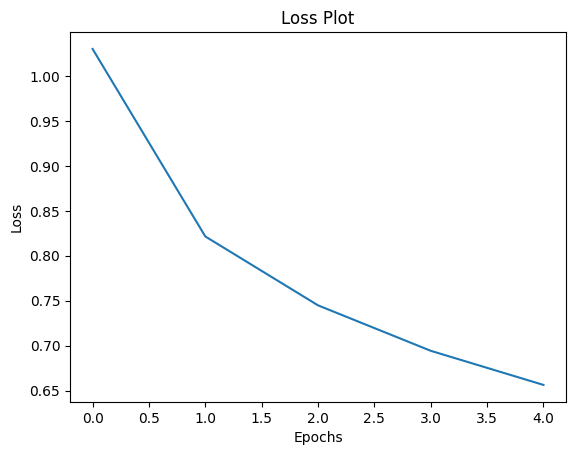

In [24]:
start_epoch = 0
loss_plot = []
num_steps = len(img_name_train) // BATCH_SIZE
best_loss = float('inf')

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0

    print(f"\n Epoch {epoch + 1}/{EPOCHS}")
    pbar = tqdm(enumerate(training_dataset), total=num_steps, desc="Training", ncols=100)

    for batch, (img_tensor, target) in pbar:
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 10 == 0:
            pbar.set_postfix({
                "Batch Loss": f"{(batch_loss.numpy() / int(target.shape[1])):.4f}"
            })

    loss_plot.append(total_loss / num_steps)
    avg_loss = total_loss / num_steps
    if avg_loss < best_loss:
        best_loss = avg_loss
        print(f"Nouvelle meilleure loss détectée ({best_loss:.6f}) → sauvegarde du modèle...")

        encoder.save(ENCODER_PATH)
        decoder.save(DECODER_PATH)

    print(f" Epoch {epoch + 1} finished - Avg Train Loss: {avg_loss:.6f}")
    print(f" Time taken: {time.time() - start:.2f} sec")

# Affichage de la courbe d'entrainement
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')

# Charger les modèles

In [ ]:
best_encoder = tf.keras.models.load_model(ENCODER_PATH, custom_objects={'CNN_Encoder': CNN_Encoder})
best_decoder = tf.keras.models.load_model(DECODER_PATH, custom_objects={'RNN_Decoder': RNN_Decoder})

## Description de la fonction `evaluate()`

La fonction `evaluate()` génère une légende automatique pour une image en utilisant un modèle Encoder-Decoder avec attention.

### Objectif
Décrire une image en texte à partir d’un modèle entraîné.

### Paramètres

- `encoder` : modèle qui encode les caractéristiques de l’image.
- `decoder` : modèle qui génère les mots de la légende.
- `image_features_extract_model` : modèle CNN pour extraire les caractéristiques de l’image.
- `tokenizer` : convertit les mots en indices et inversement.
- `max_length` : longueur maximale de la légende.
- `image_path` : chemin de l’image à décrire.

### Étapes

1. **Préparation de l’image** : chargement et extraction des caractéristiques.
2. **Encodage** : transformation des caractéristiques en vecteurs utilisables par le décodeur.
3. **Début de génération** : le décodeur commence avec le token `<start>`.
4. **Boucle de prédiction** :
   - À chaque étape, un mot est prédit.
   - Les poids d’attention sont enregistrés.
   - La boucle s’arrête si le mot `<end>` est généré ou si la longueur maximale est atteinte.
5. **Retour** :
- Liste des mots générés (résultat de la légende).  
- Matrice des poids d’attention (utilisée pour visualiser les zones importantes de l’image).

In [26]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.reset_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1,)).numpy()

        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        predicted_word = tokenizer.index_word.get(predicted_id, '<unk>')  # Use .get() to handle missing keys
        result.append(predicted_word)

        if predicted_word == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot


# Fonction permettant la représentation de l'attention au niveau de l'image
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))

    fig = plt.figure(figsize=(10, 10))

    len_result = len(result)
    grid_size = math.ceil(math.sqrt(len_result))

    for l in range(len_result):
        temp_att = np.resize(attention_plot[l], (8, 8))
        ax = fig.add_subplot(grid_size, grid_size, l + 1)
        ax.set_title(result[l])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
        ax.axis('off')  # Optionnel : retirer les axes pour un visuel plus propre

    plt.tight_layout()
    plt.show()


L'affichage de quelques exemples sur le résultat retourné par l'évaluation. 

Real Caption: <start> view of a kitchen with a stove with a shelf off bottles above and lights under the upper cabinets <end>
Prediction Caption: a break room with sink and a stove top and food all of them <end>


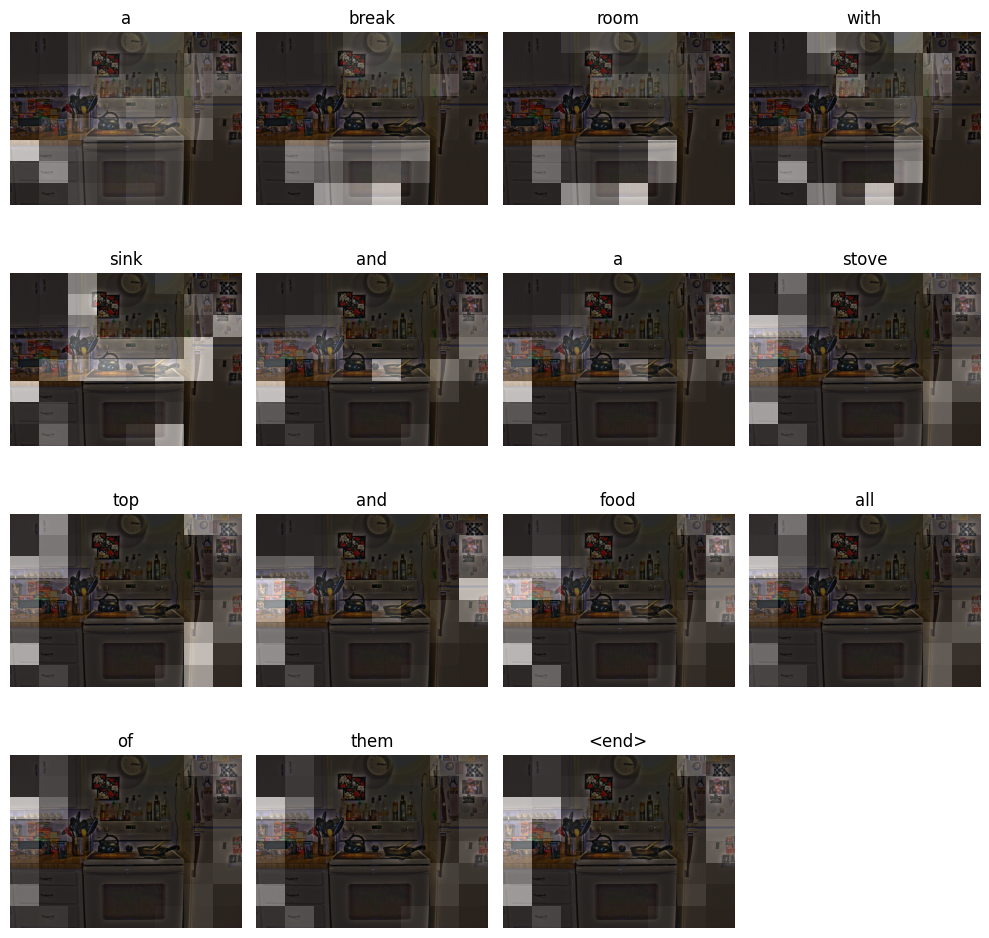

In [27]:
# Affichage de quelques annotations dans le jeu de test
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
real_caption = ' '.join([tokenizer.index_word[i] for i in cap_val[rid] if i not in [0]])
result, attention_plot = evaluate(image)

print('Real Caption:', real_caption)
print('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)

### Evaluation du model

In [30]:
nltk.download('wordnet')
nltk.download('omw-1.4')


def evaluate_metrics(img_name_val, cap_val, tokenizer, evaluate_fn, num_samples=100):
    bleu_scores = defaultdict(list)
    meteor_scores = []
    rouge_l_scores = []

    # Pour CIDEr, on prépare les formats COCO
    gts = {}  # ground truth
    res = {}  # result

    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    cider_scorer = Cider()

    for i in range(num_samples):
        image = img_name_val[i]
        real_caption = [tokenizer.index_word[idx] for idx in cap_val[i] if idx not in [0]]
        reference = ' '.join(real_caption).replace('<start>', '').replace('<end>', '').strip()

        result, _ = evaluate_fn(image)
        predicted_caption = ' '.join(result).replace('<start>', '').replace('<end>', '').strip()

        reference_tokens = [reference.split()]
        predicted_tokens = predicted_caption.split()

        # BLEU scores
        smoothing = SmoothingFunction().method1
        bleu_scores[1].append(
            sentence_bleu(reference_tokens, predicted_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing))
        bleu_scores[2].append(
            sentence_bleu(reference_tokens, predicted_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing))
        bleu_scores[3].append(sentence_bleu(reference_tokens, predicted_tokens, weights=(0.33, 0.33, 0.33, 0),
                                            smoothing_function=smoothing))
        bleu_scores[4].append(sentence_bleu(reference_tokens, predicted_tokens, weights=(0.25, 0.25, 0.25, 0.25),
                                            smoothing_function=smoothing))

        # METEOR
        # METEOR (corrigé avec tokenisation)
        meteor_scores.append(meteor_score(reference_tokens, predicted_tokens))

        # ROUGE-L
        rouge_score = scorer.score(reference, predicted_caption)['rougeL'].fmeasure
        rouge_l_scores.append(rouge_score)

        # Pour CIDEr
        gts[i] = [reference]
        res[i] = [predicted_caption]

    # Calcul final
    cider_score, _ = cider_scorer.compute_score(gts, res)

    print("\n📊 Évaluation du modèle sur", num_samples, "images:")
    print(f"BLEU-1: {sum(bleu_scores[1]) / num_samples:.4f}")
    print(f"BLEU-2: {sum(bleu_scores[2]) / num_samples:.4f}")
    print(f"BLEU-3: {sum(bleu_scores[3]) / num_samples:.4f}")
    print(f"BLEU-4: {sum(bleu_scores[4]) / num_samples:.4f}")
    print(f"METEOR: {sum(meteor_scores) / num_samples:.4f}")
    print(f"ROUGE-L: {sum(rouge_l_scores) / num_samples:.4f}")
    print(f"CIDEr: {cider_score:.4f}")

[nltk_data] Downloading package wordnet to C:\ProgramData\Workshop...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\ProgramData\Workshop...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [31]:
evaluate_metrics(img_name_val, cap_val, tokenizer, evaluate, num_samples=100)


📊 Évaluation du modèle sur 100 images:
BLEU-1: 0.1857
BLEU-2: 0.0742
BLEU-3: 0.0424
BLEU-4: 0.0298
METEOR: 0.1461
ROUGE-L: 0.2146
CIDEr: 0.1740


## Analyse des Scores d'Évaluation du Modèle

**BLEU (1 à 4)**  
- **BLEU-1 : 0.1857**  
- **BLEU-2 : 0.0742**  
- **BLEU-3 : 0.0424**  
- **BLEU-4 : 0.0298**  

**Interprétation :**  
BLEU-1 montre que le modèle prédit des mots fréquents isolés avec une meilleure précision. Les scores BLEU-2 à BLEU-4, bien qu'encore faibles, indiquent une amélioration dans la capture des relations entre les mots, mais les séquences complexes restent difficiles à générer.

---

**METEOR**  
- **Score METEOR : 0.1461**  

**Interprétation :**  
METEOR, plus tolérant que BLEU, montre une amélioration significative. Cela indique que le modèle génère des légendes plus pertinentes, même si elles ne correspondent pas exactement aux références.

---

**ROUGE-L**  
- **Score ROUGE-L : 0.2146**  

**Interprétation :**  
ROUGE-L mesure la correspondance des sous-séquences. Un score de 21.46% montre que le modèle capture mieux certaines séquences, mais il reste des marges d'amélioration pour des légendes plus longues et précises.

---

**CIDEr**  
- **Score CIDEr : 0.1740**  

**Interprétation :**  
CIDEr, qui évalue les mots rares et spécifiques, montre une nette amélioration. Cela indique que le modèle commence à utiliser des termes plus informatifs et spécifiques à l'image.

---

**Résumé Global :**  
Le modèle montre une progression notable dans la génération de légendes, avec une meilleure précision pour les mots fréquents et une utilisation accrue de termes spécifiques. Cependant, il reste des défis pour générer des descriptions complexes et riches en détails.